# VQEと量子化学

量子化学の計算では、パウリ演算子を使ってハミルトニアンを作成し、それをVQEで解くことができます。化学分野ではAnsatzに関する研究が他の問題よりも進んでおり、多くの研究者がこの問題に取り組んでいます。

##2-3-1 インストール
blueqat、openfermion、openfermionpyscf(キャッシュされた分子データが無い場合にPySCFでローカル計算するためのフォールバック用)をインストールする必要があります。

注意: ここでは `openfermionblueqat` は使用しません — 古い互換性のないバージョンのblueqatに固定されているため、代わりにHamiltonianの変換とUCC Ansatzを新しい `blueqat.utils` API に対して直接実装しています。

In [1]:
!pip install git+https://github.com/blueqat/blueqatSDK openfermion openfermionpyscf pyscf

/Users/yuichirominato/.pyenv/shims/pip: line 8: /opt/homebrew/opt/pyenv/bin/pyenv: No such file or directory


##2-3-2 コーディング
ここでは、OpenFermionによる分子データを使用します(キャッシュされたデータがローカルに無ければ、その場でPySCFを使って計算します)。

/Users/yuichirominato/blueqatSDK/.claude/worktrees/determined-mahavira-bf713e/blueqat/utils.py:399: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)
  total_matrix = torch.sparse_coo_tensor(torch.empty((2, 0), dtype=torch.int64, device=device), torch.empty(0, dtype=torch.complex128, device=device), (dim, dim))


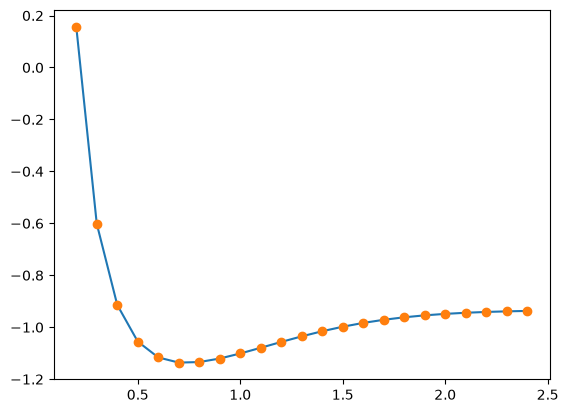

In [2]:
import numpy as np
import torch
from blueqat import Circuit
from blueqat.utils import AnsatzBase, Vqe, X, Y, Z, I
from openfermion import MolecularData, get_fermion_operator, bravyi_kitaev
from openfermionpyscf import run_pyscf

# openfermionblueqat's UCCAnsatz / Hamiltonian conversion pinned an old,
# incompatible blueqat version, so we reimplement the small pieces we need
# directly against blueqat.utils.
_PAULI = {'X': X, 'Y': Y, 'Z': Z}

def openfermion_to_blueqat(qubit_operator):
    """Convert an openfermion QubitOperator into a blueqat.utils Expr."""
    expr = 0
    for term, coeff in qubit_operator.terms.items():
        c = complex(coeff)
        t = c.real if abs(c.imag) < 1e-10 else c
        for idx, p in term:
            t = t * _PAULI[p][idx]
        expr = expr + t
    return expr

class UCCAnsatz(AnsatzBase):
    """Minimal Unitary Coupled Cluster ansatz (replaces openfermionblueqat.UCCAnsatz)."""
    def __init__(self, hamiltonian, n_step, initial_circuit):
        self.initial_circuit = initial_circuit
        super().__init__(hamiltonian.to_expr().simplify(), n_step)

    def get_circuit(self, params):
        c = self.initial_circuit.copy()
        for t in params:
            for term in self.hamiltonian.terms:
                term.get_time_evolution()(c, t * torch.pi)
        return c

def get_molecule(bond_len):
  geometry = [('H',(0.,0.,0.)),('H',(0.,0.,bond_len))]

  description = format(bond_len)
  molecule = MolecularData(geometry, "sto-3g",1,description=description)

  try:
      molecule.load()
  except (FileNotFoundError, OSError, KeyError):
      # No cached data found: compute Hartree-Fock/FCI with PySCF instead.
      molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
      molecule.save()
  return molecule

x = [];e=[];fullci=[]
for bond_len in np.arange(0.2,2.5,0.1):
  m = get_molecule(float("{:.2}".format(bond_len)))
  h = openfermion_to_blueqat(bravyi_kitaev(get_fermion_operator(m.get_molecular_hamiltonian())))
  runner = Vqe(UCCAnsatz(h,6,Circuit().x[0]))
  result = runner.run()
  x.append(bond_len)
  e.append(runner.ansatz.get_energy_sparse(result.circuit).item())
  fullci.append(m.fci_energy)

%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(x,fullci)
plt.plot(x,e,"o")

H2の問題について結果が得られました。

##2-3-3 コード内部の確認
OpenFermionのMoluculearData関数を使うことで、H2分子のSto-3gの用意されたデータを利用できます。

In [3]:
def get_molecule(bond_len):
  geometry = [('H',(0.,0.,0.)),('H',(0.,0.,bond_len))]

  description = format(bond_len)
  molecule = MolecularData(geometry, "sto-3g",1,description=description)

  try:
      molecule.load()
  except (FileNotFoundError, OSError, KeyError):
      # No cached data found: compute Hartree-Fock/FCI with PySCF instead.
      molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
      molecule.save()
  return molecule

ここでは原子間の結合長として0.4を選びます。第二量子化での定式化を得ます。

In [4]:
m = get_molecule(0.4)
m.get_molecular_hamiltonian()

() 1.322943021475
((0, 1), (0, 0)) -1.4820918858979102
((1, 1), (1, 0)) -1.4820918858979102
((2, 1), (2, 0)) -0.1187350527865787
((3, 1), (3, 0)) -0.1187350527865787
((0, 1), (0, 1), (0, 0), (0, 0)) 0.36843967630348756
((0, 1), (0, 1), (2, 0), (2, 0)) 0.08225771204699692
((0, 1), (1, 1), (1, 0), (0, 0)) 0.36843967630348756
((0, 1), (1, 1), (3, 0), (2, 0)) 0.08225771204699692
((0, 1), (2, 1), (0, 0), (2, 0)) 0.082257712046997
((0, 1), (2, 1), (2, 0), (0, 0)) 0.3626667179796745
((0, 1), (3, 1), (1, 0), (2, 0)) 0.082257712046997
((0, 1), (3, 1), (3, 0), (0, 0)) 0.3626667179796745
((1, 1), (0, 1), (0, 0), (1, 0)) 0.36843967630348756
((1, 1), (0, 1), (2, 0), (3, 0)) 0.08225771204699692
((1, 1), (1, 1), (1, 0), (1, 0)) 0.36843967630348756
((1, 1), (1, 1), (3, 0), (3, 0)) 0.08225771204699692
((1, 1), (2, 1), (0, 0), (3, 0)) 0.082257712046997
((1, 1), (2, 1), (2, 0), (1, 0)) 0.3626667179796745
((1, 1), (3, 1), (1, 0), (3, 0)) 0.082257712046997
((1, 1), (3, 1), (3, 0), (1, 0)) 0.362666717979674

これはパウリ演算子によるハミルトニアンではないため、変換が必要です。

##2-3-4 変換

Bravyi-Kitaev変換とJordan-Wigner変換が有名です。ここでは前者のBK変換を使用します。

In [5]:
h_of = bravyi_kitaev(get_fermion_operator(m.get_molecular_hamiltonian()))
h = openfermion_to_blueqat(h_of)
print(h)

0.7407724940116754*I + 0.23528824284103544*Z[0] + 0.23528824284103542*Z[0]*Z[1] + -0.45353118471995524*Z[2] + -0.45353118471995524*Z[1]*Z[2]*Z[3] + 0.18421983815174378*Z[1] + 0.041128856023498556*Y[0]*Z[1]*Y[2]*Z[3] + 0.041128856023498556*X[0]*Z[1]*X[2] + 0.041128856023498556*X[0]*Z[1]*X[2]*Z[3] + 0.041128856023498556*Y[0]*Z[1]*Y[2] + 0.14020450296633868*Z[0]*Z[2] + 0.18133335898983727*Z[0]*Z[1]*Z[2]*Z[3] + 0.18133335898983727*Z[0]*Z[1]*Z[2] + 0.14020450296633868*Z[0]*Z[2]*Z[3] + 0.19136084915706864*Z[1]*Z[3]


これでパウリ演算子によるハミルトニアンが得られたので、VQEで解くことができます。効率よく解くために、AnsatzにUCC理論を使用します。blueqatで自作したUCCAnsatzを使うと、

In [6]:
runner = Vqe(UCCAnsatz(h,2,Circuit().x[0]))
result = runner.run(verbose = True)

最適化プロセスの後、最小化された結果が得られます。今回はUCC Ansatzをハミルトニアンとともに使用します。

In [7]:
runner.ansatz.get_energy_sparse(result.circuit)

tensor(-0.9141, dtype=torch.float64)

改めて、H2のUCC Ansatzの全体のコードは以下の通りです。

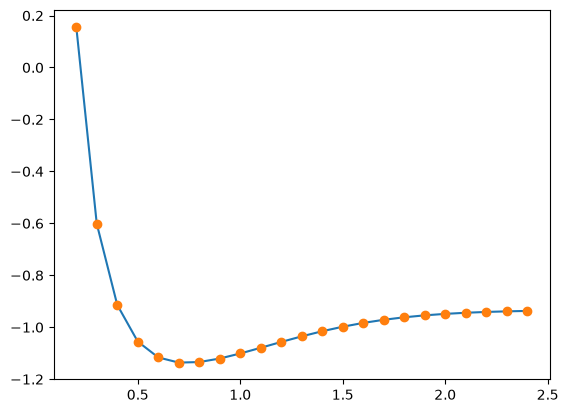

In [8]:
import numpy as np
import torch
from blueqat import Circuit
from blueqat.utils import AnsatzBase, Vqe, X, Y, Z, I
from openfermion import MolecularData, get_fermion_operator, bravyi_kitaev
from openfermionpyscf import run_pyscf

x = [];e=[];fullci=[]
for bond_len in np.arange(0.2,2.5,0.1):
  m = get_molecule(float("{:.2}".format(bond_len)))
  h = openfermion_to_blueqat(bravyi_kitaev(get_fermion_operator(m.get_molecular_hamiltonian())))
  runner = Vqe(UCCAnsatz(h,6,Circuit().x[0]))
  result = runner.run()
  x.append(bond_len)
  e.append(runner.ansatz.get_energy_sparse(result.circuit).item())
  fullci.append(m.fci_energy)

%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(x,fullci)
plt.plot(x,e,"o")